•	Loading CSV files with pandas
•	Data exploration
•	Summary statistics
•	Data visualization

loading the data set

In [25]:
import pandas as pd
df = pd.read_csv("student_performance.csv", delimiter=';')
df = df.drop(0, axis=0)
df.columns = ["Student ID", "Study Hours", "Attendance", "Sleep Hours", "Exam Score"]
#df.head(100)
pd.set_option('display.max_row', 100)
df.head(100)

,Student ID,Study Hours,Attendance,Sleep Hours,Exam Score
1,UON/SCI/24/015,4.0,93.0,6.0,75.0
2,UON/SCI/24/028,8.0,92.0,4.0,83.0
3,UON/SCI/24/042,5.0,82.0,4.0,68.0
4,UON/SCI/24/055,7.0,83.0,7.0,96.0
5,UON/SCI/24/068,10.0,96.0,6.0,100.0
6,UON/SCI/24/081,3.0,94.0,9.0,71.0
7,UON/SCI/24/094,7.0,99.0,8.0,92.0
8,UON/SCI/24/007,8.0,81.0,6.0,87.0
9,UON/SCI/24/020,5.0,86.0,7.0,72.0
10,UON/SCI/24/033,4.0,94.0,7.0,75.0


In [26]:
df.isnull().sum()

Student ID     0
Study Hours    3
Attendance     3
Sleep Hours    3
Exam Score     2
dtype: int64

In [27]:
#stats
df.describe()

,Study Hours,Attendance,Sleep Hours,Exam Score
count,96.0000,96.000000,96.000000,97.000000
mean,5.8125,81.114583,6.385417,74.804124
std,2.8812,12.658985,1.731259,15.630259
min,1.0000,60.000000,4.000000,42.000000
25%,3.0000,70.000000,5.000000,65.000000
50%,6.0000,83.500000,6.000000,76.000000
75%,8.0000,92.000000,8.000000,87.000000
max,10.0000,100.000000,9.000000,100.000000


Working with correlation

In [28]:
df.corr(numeric_only=True)

,Study Hours,Attendance,Sleep Hours,Exam Score
Study Hours,1.000000,-0.124394,-0.171459,0.847700
Attendance,-0.124394,1.000000,0.015468,0.200423
Sleep Hours,-0.171459,0.015468,1.000000,0.145105
Exam Score,0.847700,0.200423,0.145105,1.000000


filling the missing gabs with mean value

In [29]:
df = df.fillna(df.select_dtypes(include='number').mean().round(0))
df.head(100)

,Student ID,Study Hours,Attendance,Sleep Hours,Exam Score
1,UON/SCI/24/015,4.0,93.0,6.0,75.0
2,UON/SCI/24/028,8.0,92.0,4.0,83.0
3,UON/SCI/24/042,5.0,82.0,4.0,68.0
4,UON/SCI/24/055,7.0,83.0,7.0,96.0
5,UON/SCI/24/068,10.0,96.0,6.0,100.0
6,UON/SCI/24/081,3.0,94.0,9.0,71.0
7,UON/SCI/24/094,7.0,99.0,8.0,92.0
8,UON/SCI/24/007,8.0,81.0,6.0,87.0
9,UON/SCI/24/020,5.0,86.0,7.0,72.0
10,UON/SCI/24/033,4.0,94.0,7.0,75.0


Calculating mean_score, max_score & min_score


In [30]:
mean_score = np.array(df['Exam Score']).mean()
print("The mean value of exam score is:", mean_score)

max_score = np.array(df['Exam Score']).max()
print("The maximun exam score is:", max_score)

min_score = np.array(df['Exam Score']).min()
print("The miniimun exam score is:", min_score)

The mean value of exam score is: 74.8080808080808
The maximun exam score is: 100.0
The miniimun exam score is: 42.0


Ploting Histogram of Exam Scores

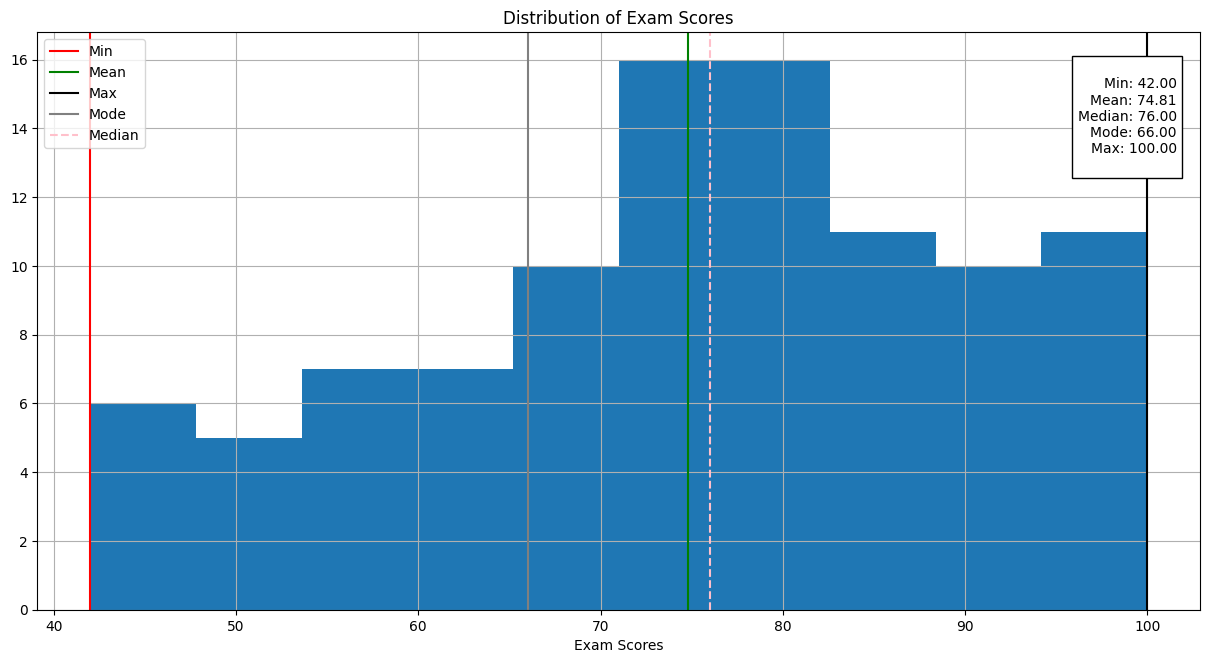

In [31]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
fig = plt.figure(figsize=(15,7.5))
df['Exam Score'].hist(bins=10)
plt.xlabel("Exam Scores")
plt.title("Distribution of Exam Scores")

# calculating statistics data
data = df['Exam Score']
min_value = np.min(data)
max_value = np.max(data)
mid_value = np.mean(data)
med_value = np.median(data)
mod_value = data.mode()[0]

#DISPLAYING A STATISTICS VALUE AT RIGHT TOP SIDE OF THE CHART
#checking axis limits
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()

# top-right position
x = xmax - (xmax - xmin) * 0.02
y = ymax * 0.95

# vertical lines
plt.axvline(x=min_value, color='red', label='Min')
plt.axvline(x=mid_value, color='green', label='Mean')
plt.axvline(x=max_value, color='black', label='Max')
plt.axvline(x=mod_value, color='gray', label='Mode')
plt.axvline(x=med_value, color='pink', linestyle='--', label='Median')

# statistics text
stats_text = f'''
Min: {min_value:.2f}
Mean: {mid_value:.2f}
Median: {med_value:.2f}
Mode: {mod_value:.2f}
Max: {max_value:.2f}
'''

plt.text(x, y, stats_text, ha='right', va='top', bbox=dict(facecolor='white'))
plt.legend()
plt.show()

Ploting of Scatter plot (Study Hours vs Score)



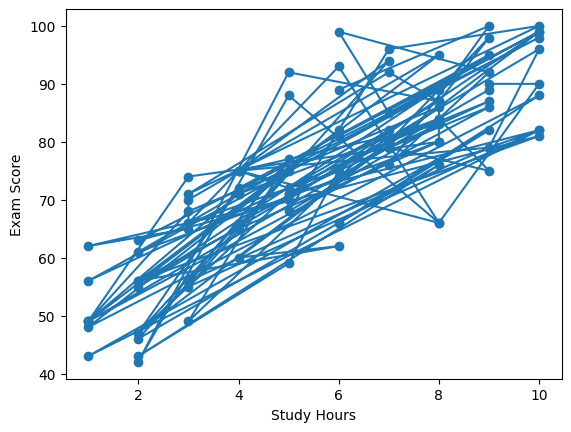

In [32]:
plt.scatter(df["Study Hours"], df["Exam Score"])
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.plot(df['Study Hours'], df['Exam Score'])
plt.show()

Creating Boxplot of scores

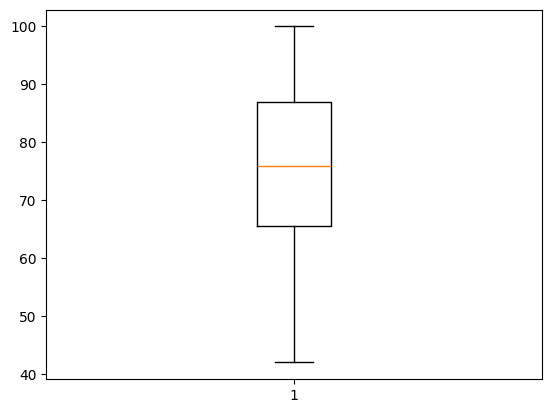

In [35]:
plt.boxplot(df['Exam Score'])
plt.show()

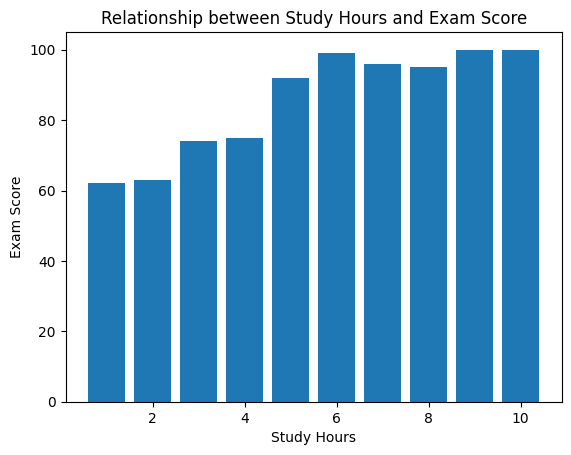

In [39]:
plt.bar(df["Study Hours"], df["Exam Score"])
plt.ylabel("Exam Score")
plt.xlabel("Study Hours")
plt.title("Relationship between Study Hours and Exam Score")
plt.show()